# BraggCalculator: complete diffraction characterization tutorial

**An executable, standalone companion to the guided UI**

This notebook follows one materials-characterization question from raw files to
an auditable scientific conclusion:

> Can a synthetic Cu Kα powder experiment distinguish a reference NaSiO₂ motif
> from a candidate with shifted oxygen sites?

We simulate diffraction, inspect reflections, classify the structural
relationship, locate information loss, compare complex structure factors,
study peak overlap and pair distributions, refine both candidates fairly,
inspect local identifiability, and ask which new measurement would add
information. Every diagnostic has three layers:

1. **Layman's view** — what it means in ordinary language.
2. **Theory and mathematics** — what is actually calculated.
3. **What to look for** — how to interpret it without overclaiming.

> **Scope warning.** The bundled pattern is synthetic teaching data, not
> independent experimental validation. It is deliberately ambiguous. A low
> profile residual is evidence of agreement with this pattern; it is not, by
> itself, proof that a structure is correct.


## 0. Reproducible setup

The notebook uses only versioned package data. The project created below copies
and hashes every input. Re-running replaces only
`notebooks/tutorial-output/`, which is intentionally ignored by Git.

Install the development environment with `poetry install --extras torch`, then
run from the repository root. A CPU is sufficient.


In [1]:
from __future__ import annotations

from importlib.resources import files
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from pymatgen.core import Structure

import braggcalculator
from braggcalculator import (
    BraggCalculator, DiffractionDataset, OptimizationStage, ProjectStore,
    RefinementPolicy, diagnose_structures, suggest_measurements,
)
from braggcalculator.diagnostics import compare_calculators

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

ROOT = Path.cwd().resolve()
if not (ROOT / "braggcalculator").is_dir():
    ROOT = next(
        (parent for parent in ROOT.parents
         if (parent / "braggcalculator").is_dir()), ROOT
    )
DATA = Path(str(files("braggcalculator") / "tutorial_data"))
OUTPUT = (ROOT / "notebooks" / "tutorial-output").resolve()
if OUTPUT.exists():
    if OUTPUT.name != "tutorial-output":
        raise RuntimeError("Refusing to replace an unexpected output directory")
    shutil.rmtree(OUTPUT)
OUTPUT.mkdir(parents=True)

MODEL_A = DATA / "model-a.cif"
MODEL_B = DATA / "model-b.cif"
PATTERN = DATA / "pattern.xye"
def shown(path):
    path = Path(path).resolve()
    try:
        return path.relative_to(ROOT)
    except ValueError:
        return path

print(f"BraggCalculator {braggcalculator.__version__}")
print(f"Inputs: {shown(DATA)}")
print(f"Generated project: {shown(OUTPUT)}")


BraggCalculator 0.1.0
Inputs: braggcalculator/tutorial_data
Generated project: notebooks/tutorial-output


## 1. Read the experiment and candidate structures

### Layman's view

The XYE file contains angle, measured intensity, and one-standard-deviation
uncertainty. The CIF files contain periodic unit cells and fractional atomic
coordinates. Uncertainty matters: a 10-count difference is compelling when
σ is 1, but uninformative when σ is 100.

### Theory and mathematics

For independent Gaussian observations each point receives weight
$w_i=1/\sigma_i^2$. BraggCalculator preserves the input hash, units, radiation,
wavelength, uncertainty interpretation, and mask; these become part of every
refinement result.

### What to look for

Confirm a strictly increasing coordinate, positive σ, correct radiation and
wavelength, and chemically plausible CIFs before fitting anything.


{'points': 801,
 '2theta range (degrees)': (np.float64(18.0), np.float64(82.0)),
 'step (degrees)': 0.0799999999999983,
 'source SHA256': '0aec3e605d4e533ee2ccaaab602415d530f47fee4e07ef89ffcc9a7a559a49c6',
 'model A': ('NaSiO2', 4),
 'model B': ('NaSiO2', 4)}

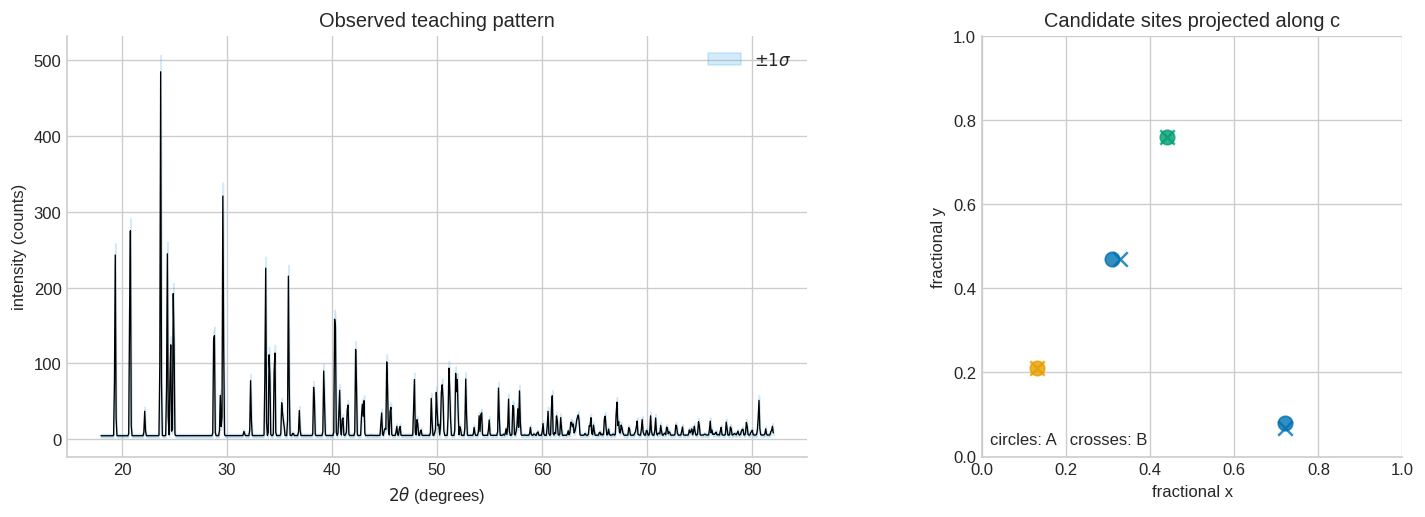

In [2]:
dataset = DiffractionDataset.from_xye(
    PATTERN, wavelength=1.5406, radiation="xray", third_column="sigma",
    metadata={"purpose": "synthetic tutorial; not external validation"},
)
structure_a = Structure.from_file(MODEL_A)
structure_b = Structure.from_file(MODEL_B)
display({
    "points": len(dataset.coordinate),
    "2theta range (degrees)": (dataset.coordinate[0], dataset.coordinate[-1]),
    "step (degrees)": dataset.step,
    "source SHA256": dataset.source_sha256,
    "model A": (structure_a.composition.reduced_formula, len(structure_a)),
    "model B": (structure_b.composition.reduced_formula, len(structure_b)),
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), constrained_layout=True)
axes[0].plot(dataset.coordinate, dataset.intensity, color="black", lw=0.8)
axes[0].fill_between(
    dataset.coordinate, dataset.intensity-dataset.sigma,
    dataset.intensity+dataset.sigma, color="#56B4E9", alpha=0.25,
    label=r"$\pm 1\sigma$",
)
axes[0].set(xlabel=r"$2\theta$ (degrees)", ylabel="intensity (counts)",
            title="Observed teaching pattern")
axes[0].legend()
colors = {"Si": "#E69F00", "O": "#0072B2", "Na": "#009E73"}
for structure, marker in ((structure_a, "o"), (structure_b, "x")):
    for site in structure:
        axes[1].scatter(*site.frac_coords[:2], marker=marker, s=75,
                        color=colors.get(site.species_string, "0.4"), alpha=0.8)
axes[1].set(xlabel="fractional x", ylabel="fractional y", xlim=(0, 1),
            ylim=(0, 1), aspect="equal",
            title="Candidate sites projected along c")
axes[1].text(0.02, 0.03, "circles: A   crosses: B",
             transform=axes[1].transAxes)
plt.show()


## 2. Forward simulation: structure → reflections → powder profile

### Layman's view

Every atom scatters the incident wave. For one reflection those waves add as
complex arrows: some reinforce and some cancel. A powder instrument measures
intensities after directional averaging and broadening.

### Theory and mathematics

For $\mathbf G_{\mathbf h}=2\pi\mathbf A^{-T}\mathbf h$,

$$F_{\mathbf h}=\sum_j o_j f_j(Q)
\exp[-\tfrac12\mathbf G_{\mathbf h}^{T}\mathbf U_j\mathbf G_{\mathbf h}]
\exp(2\pi i\mathbf h^T\mathbf x_j).$$

Reflection area is proportional to $|F_{\mathbf h}|^2$ after multiplicity and
geometry corrections, while

$$I_{calc}(q_i)=B(q_i)+\sum_{\mathbf h}A_{\mathbf h}
\phi(q_i-q_{\mathbf h}).$$

The complex $F$, reflection table, and broadened profile remain separate so we
can locate where structural information disappears.

### What to look for

Sticks are reciprocal reflections; one visible powder peak can contain several.
Position is mainly lattice information, area mainly structure-factor information,
and shape mainly instrument/sample information.


[{'hkl': (1, 0, 1),
  'd (angstrom)': 3.7547508139285894,
  '2theta (degrees)': 23.676961422060916,
  '|F| squared': 478.36440483573494,
  'corrected intensity': 21352.92384693744},
 {'hkl': (-1, 0, -1),
  'd (angstrom)': 3.7547508139285894,
  '2theta (degrees)': 23.676961422060916,
  '|F| squared': 478.36440483573494,
  'corrected intensity': 21352.92384693744},
 {'hkl': (1, -1, 0),
  'd (angstrom)': 3.0137294683205313,
  '2theta (degrees)': 29.617917855950047,
  '|F| squared': 551.362155904917,
  'corrected intensity': 15327.094952186531},
 {'hkl': (-1, 1, 0),
  'd (angstrom)': 3.0137294683205313,
  '2theta (degrees)': 29.617917855950047,
  '|F| squared': 551.362155904917,
  'corrected intensity': 15327.094952186531},
 {'hkl': (0, -1, -1),
  'd (angstrom)': 4.272849100232454,
  '2theta (degrees)': 20.771887050366324,
  '|F| squared': 254.70492844725953,
  'corrected intensity': 14933.06102923508},
 {'hkl': (0, 1, 1),
  'd (angstrom)': 4.272849100232454,
  '2theta (degrees)': 20.77188

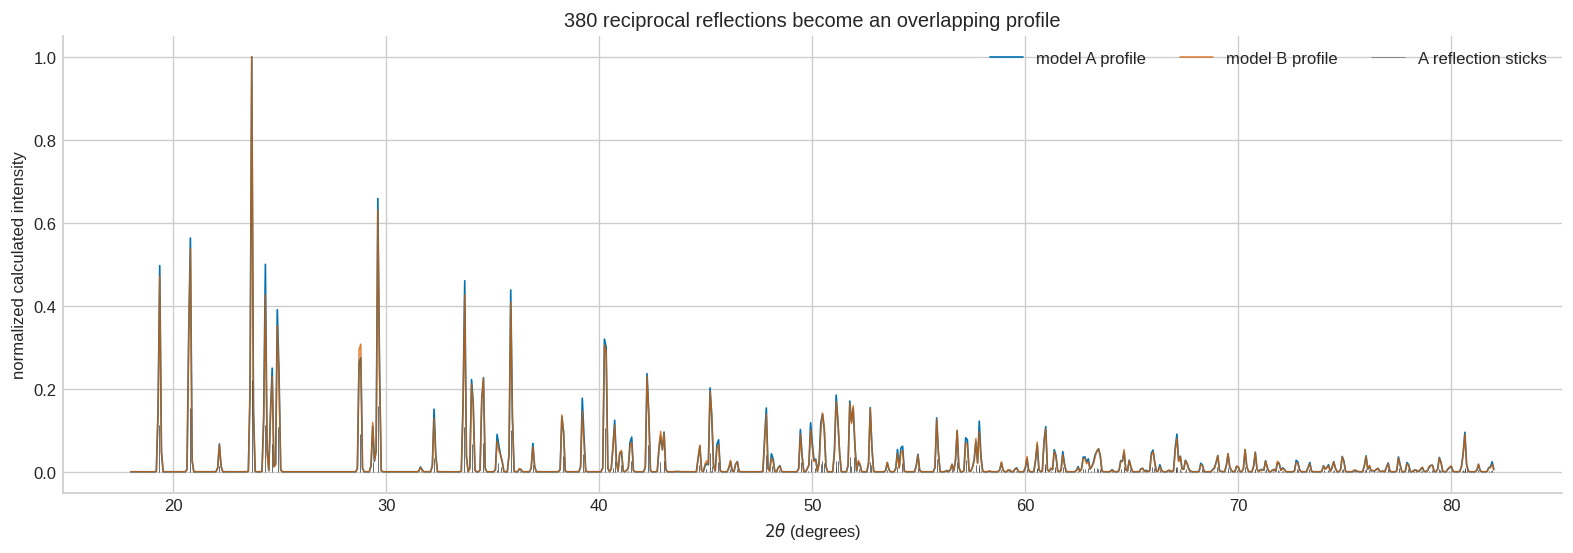

In [3]:
settings = dict(
    mode="xray", wavelength=dataset.wavelength, primitive=False,
    two_theta_range=(dataset.coordinate[0], dataset.coordinate[-1]),
    two_theta_step=dataset.step,
)
calculator_a = BraggCalculator(**settings).load(structure_a)
calculator_b = BraggCalculator(**settings).load(structure_b)
table_a = calculator_a.reflection_table(domain="two_theta")
grid_a, profile_a = calculator_a.pattern(domain="two_theta")
grid_b, profile_b = calculator_b.pattern(domain="two_theta")
profile_a, profile_b = np.asarray(profile_a), np.asarray(profile_b)

strongest = np.argsort(np.asarray(table_a.intensity))[-8:][::-1]
display([{
    "hkl": tuple(int(v) for v in table_a.hkl[i]),
    "d (angstrom)": float(np.asarray(table_a.d_spacing)[i]),
    "2theta (degrees)": float(np.asarray(table_a.two_theta)[i]),
    "|F| squared": float(np.asarray(table_a.f_squared)[i]),
    "corrected intensity": float(np.asarray(table_a.intensity)[i]),
} for i in strongest])

fig, ax = plt.subplots(figsize=(13, 4.5), constrained_layout=True)
ax.plot(grid_a, profile_a/max(profile_a.max(), 1), color="#0072B2", lw=1,
        label="model A profile")
ax.plot(grid_b, profile_b/max(profile_b.max(), 1), color="#D55E00", lw=0.9,
        alpha=0.8, label="model B profile")
sticks = np.asarray(table_a.intensity)
sticks = 0.22*sticks/max(sticks.max(), 1)
ax.vlines(np.asarray(table_a.two_theta), 0, sticks, color="0.25", lw=0.45,
          alpha=0.65, label="A reflection sticks")
ax.set(xlabel=r"$2\theta$ (degrees)",
       ylabel="normalized calculated intensity",
       title=f"{len(table_a)} reciprocal reflections become an overlapping profile")
ax.legend(ncol=3)
plt.show()


## 3. Relationship classification and the information-loss ladder

### Layman's view

Reflection (hkl) can be compared as a complex number only when it means the same
reciprocal vector in both structures. Compatible cells can be aligned; unrelated
polymorphs cannot be given an invented phase correspondence.

### Theory and mathematics

Regime **I** is equivalent/lattice-compatible, **II** is commensurate
parent/supercell, and **III** is unrelated/noncommensurate. The engine then follows

$$\rho(\mathbf r)\rightarrow F(\mathbf G)\rightarrow |F|^2
\rightarrow I_{stick}(Q)\rightarrow I_{profile}(Q).$$

The arrows discard phase, reciprocal-space direction, peak separation, and finally
signal relative to noise.

### What to look for

Read the regime and reason first. Then compare similarity from left to right; a
large increase identifies the operation that hides a model difference.


{'regime': 'I',
 'classification': 'lattice_compatible',
 'complex comparison allowed': True,
 'reason': 'The direct lattice matrices coincide but the decorated structures differ.',
 'dominant information-loss label': 'phase_loss',
 'explanation': 'Discarding calculated phases produces the largest similarity increase.'}

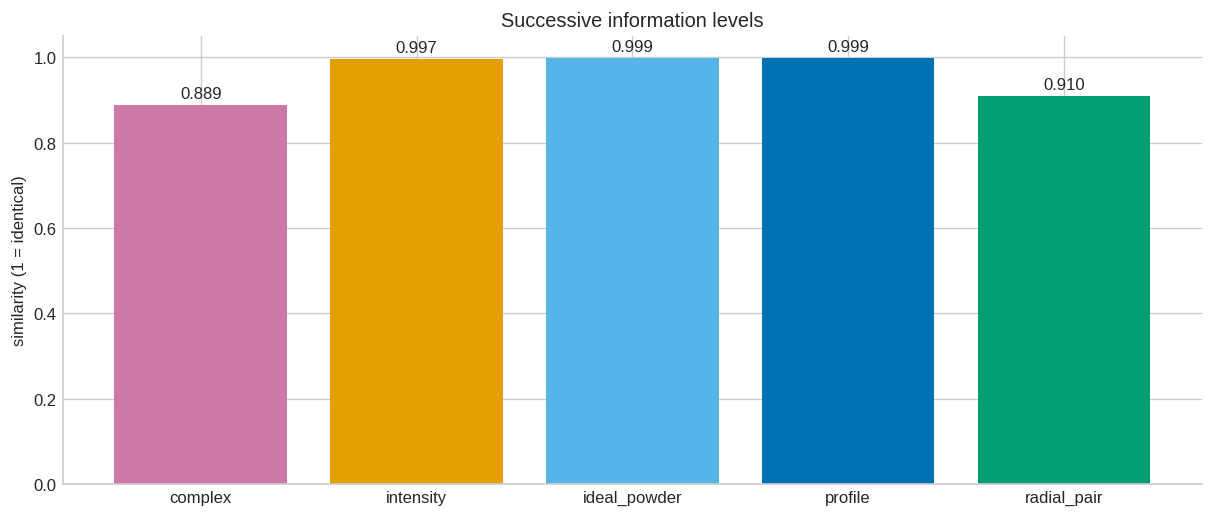

In [4]:
diagnostic = diagnose_structures(
    structure_a, structure_b, radiation="xray", wavelength=1.5406,
    q_range=(0.5, 5.0), q_step=0.015, profile_fwhm_q=0.08,
    count_scale=100.0, background_density=1.0,
    site_groups={"silicon": [0], "oxygen": [1, 2], "sodium": [3]},
    counterfactual_groups={"silicon": [0], "oxygen": [1, 2], "sodium": [3]},
)
display({
    "regime": diagnostic.relationship.regime,
    "classification": diagnostic.relationship.classification,
    "complex comparison allowed": diagnostic.relationship.complex_comparison_allowed,
    "reason": diagnostic.relationship.reason,
    "dominant information-loss label": diagnostic.dominant_information_loss,
    "explanation": diagnostic.explanation,
})
labels = list(diagnostic.similarities)
values = [diagnostic.similarities[name] for name in labels]
fig, ax = plt.subplots(figsize=(10, 4.2), constrained_layout=True)
bars = ax.bar(labels, [np.nan if v is None else v for v in values],
              color=["#CC79A7", "#E69F00", "#56B4E9", "#0072B2", "#009E73"])
ax.set(ylim=(0, 1.05), ylabel="similarity (1 = identical)",
       title="Successive information levels")
for bar, value in zip(bars, values):
    if value is not None:
        ax.text(bar.get_x()+bar.get_width()/2, value+0.015, f"{value:.3f}",
                ha="center")
plt.show()


## 4. The amplitude–phase mismatch disk

### Layman's view

A structure factor is a complex arrow. The disk separates wrong arrow length
(horizontal) from wrong direction (vertical). Powder intensity retains length
squared but discards direction, so vertical disagreement can be real yet invisible.

### Theory and mathematics

After valid lattice/origin alignment, with $a=|F_A|$, $b=|F_B|$ and phase
difference $\Delta\phi$,

$$x={b-a\over a+b+\epsilon},\qquad
y={2\sqrt{ab}\over a+b+\epsilon}\sin(\Delta\phi/2),$$

$$r^2=x^2+y^2={|F_B-F_A|^2\over(|F_A|+|F_B|+\epsilon)^2}\leq1,$$

and $D_{SF}^2=D_{amp}^2+D_{phase}^2$.

### What to look for

Center means agreement; left/right means weaker/stronger amplitude in B; vertical
spread means phase disagreement; boundary points often indicate extinction
mismatch. Never use this disk for unrelated lattices without a valid mapping.


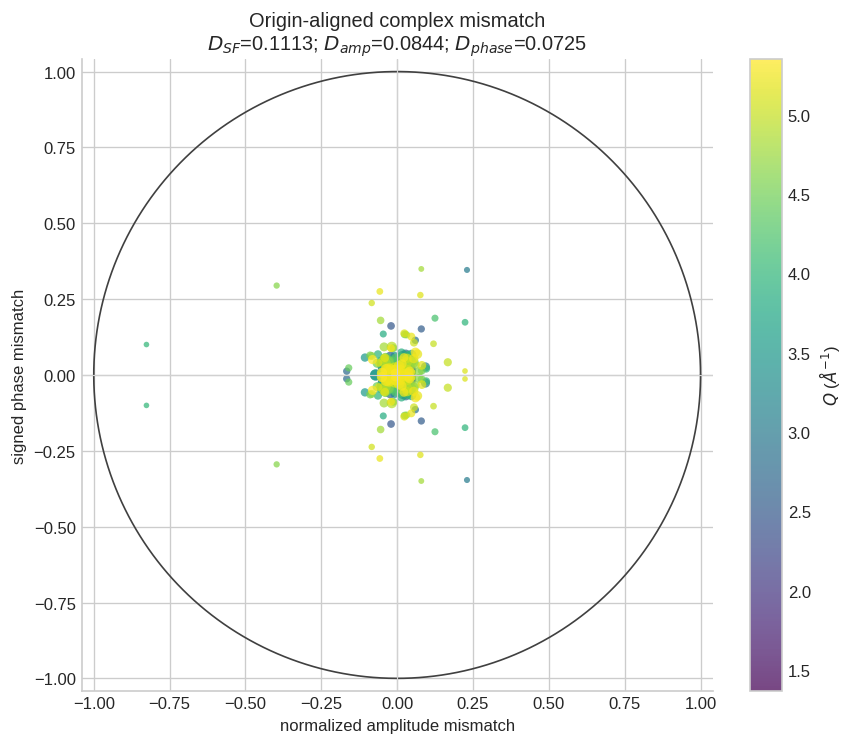

Optimal origin correction: [0.996826 0.001465 0.998779]
Disk-identity numerical error: 3.33e-16


In [5]:
mismatch = compare_calculators(
    calculator_a, calculator_b, domain="two_theta", optimize_origin=True
)
matched_q = np.asarray(table_a.q)[mismatch.match.indices_a]
amplitudes = mismatch.amplitude_a + mismatch.amplitude_b
point_size = 10 + 70*amplitudes/max(float(amplitudes.max()), 1)
fig, ax = plt.subplots(figsize=(7.2, 6.1), constrained_layout=True)
angle = np.linspace(0, 2*np.pi, 500)
ax.plot(np.cos(angle), np.sin(angle), color="0.25", lw=1)
points = ax.scatter(mismatch.x, mismatch.y, c=matched_q, s=point_size,
                    cmap="viridis", alpha=0.72, edgecolors="none")
ax.axhline(0, color="0.82", lw=0.7); ax.axvline(0, color="0.82", lw=0.7)
ax.set(aspect="equal", xlim=(-1.04, 1.04), ylim=(-1.04, 1.04),
       xlabel="normalized amplitude mismatch", ylabel="signed phase mismatch",
       title=(f"Origin-aligned complex mismatch\n$D_{{SF}}$={mismatch.d_sf:.4f}; "
              f"$D_{{amp}}$={mismatch.d_amplitude:.4f}; "
              f"$D_{{phase}}$={mismatch.d_phase:.4f}"))
fig.colorbar(points, ax=ax, label=r"$Q$ ($\AA^{-1}$)")
plt.show()
print("Optimal origin correction:", np.round(mismatch.alignment.shift, 6))
print(f"Disk-identity numerical error: {mismatch.identity_error:.2e}")


## 5. Pair distributions, peak overlap, and counterfactual attribution

### Layman's view

Pair distributions ask whether both models contain similar scattering-weighted
distances. Peak groups ask how many reciprocal reflections the instrument merges
into one visible feature. Counterfactuals replace one declared site group at a
time to show which motif can reproduce the model-to-model profile change.

### Theory and mathematics

For normalized reflection contributions $p_h$, the effective number in one
resolution-defined group is
$N_{eff}=\exp[-\sum_h p_h\log p_h]$. One means a single dominant reflection;
larger values mean heavier mixing.

### What to look for

High pair similarity suggests common local/heavy-atom geometry, not identical
topology. Large $N_{eff}$ warns against assigning a visible peak to one (hkl).
Counterfactual site effects are model interventions, not experimentally isolated
atomic intensities.


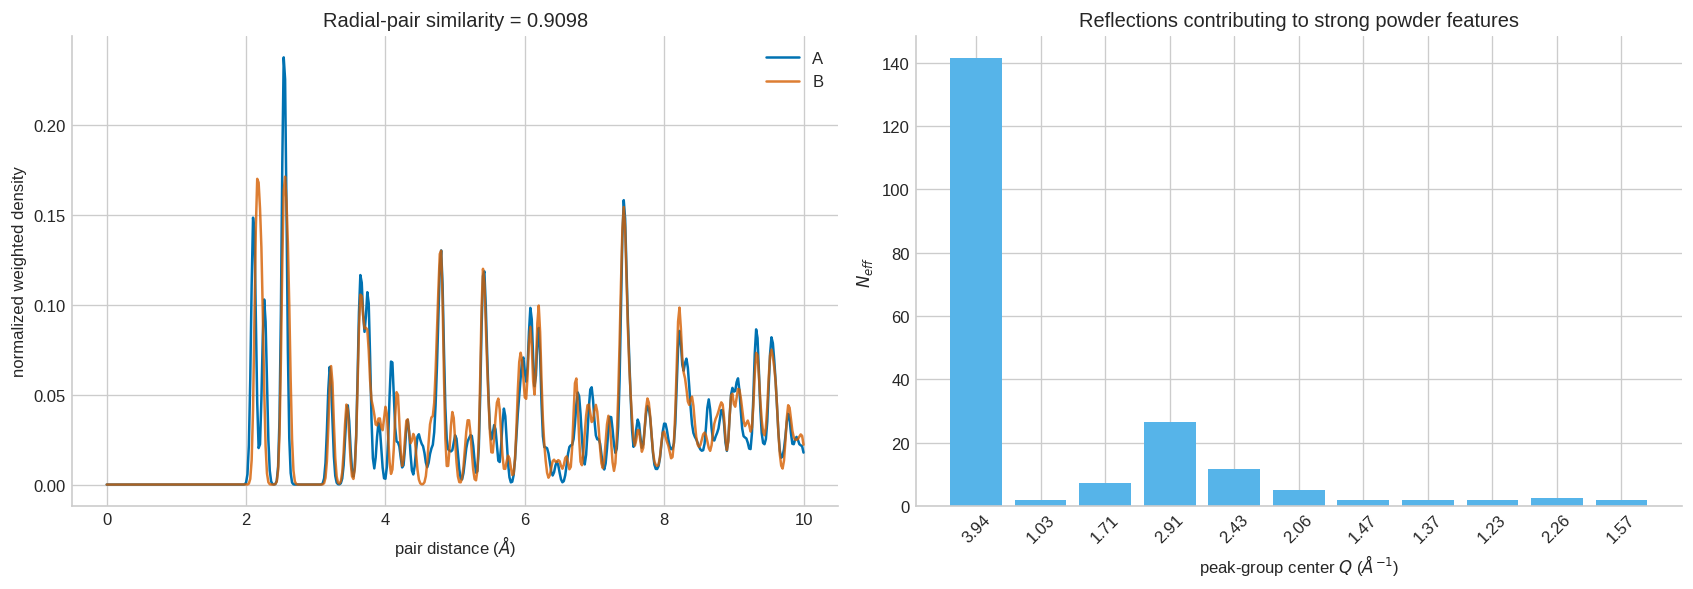

[{'group': 'silicon',
  'profile-effect norm': 0.0,
  'alignment with full A-to-B change': 0.0,
  'largest-effect Q': 0.5},
 {'group': 'oxygen',
  'profile-effect norm': 0.555661690347581,
  'alignment with full A-to-B change': 0.3958015616991681,
  'largest-effect Q': 1.7449999999999999},
 {'group': 'sodium',
  'profile-effect norm': 0.7754945368016869,
  'alignment with full A-to-B change': 0.6923341333793013,
  'largest-effect Q': 1.04}]

In [6]:
pair = diagnostic.pair_distribution
groups = sorted(diagnostic.peak_groups_a,
                key=lambda item: item.integrated_intensity, reverse=True)[:12]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
axes[0].plot(pair.radius, pair.distribution_a, color="#0072B2", label="A")
axes[0].plot(pair.radius, pair.distribution_b, color="#D55E00", alpha=0.8,
             label="B")
axes[0].set(xlabel=r"pair distance ($\AA$)",
            ylabel="normalized weighted density",
            title=f"Radial-pair similarity = {pair.similarity:.4f}")
axes[0].legend()
axes[1].bar(np.arange(len(groups)), [g.effective_reflections for g in groups],
            color="#56B4E9")
axes[1].set(xticks=np.arange(len(groups)),
            xticklabels=[f"{g.q_center:.2f}" for g in groups],
            xlabel=r"peak-group center $Q$ ($\AA^{-1}$)", ylabel=r"$N_{eff}$",
            title="Reflections contributing to strong powder features")
axes[1].tick_params(axis="x", rotation=45)
plt.show()
display([{
    "group": item.name, "profile-effect norm": item.effect_norm,
    "alignment with full A-to-B change": item.alignment_fraction,
    "largest-effect Q": item.largest_effect_coordinate,
} for item in diagnostic.counterfactuals])


## 6. Experimental discriminability: is the difference measurable?

### Layman's view

Two theoretical curves can differ while a real instrument cannot tell them apart.
Dividing by expected uncertainty changes the question from “are they different?”
to “would this experiment notice?”

### Theory and mathematics

For independent bins,
$$d_i={\mu_{A,i}-\mu_{B,i}\over\sigma_i},\quad
\mathcal D_i=d_i^2,\quad\mathcal D_{total}=\sum_i d_i^2.$$
Under the Gaussian model this is expected $\Delta\chi^2$ between fixed profiles.
Full covariance is handled by whitening, where unique pointwise attribution is not
claimed.

This first plot uses an explicit *hypothetical* count model for the unrefined
structures. The refinement later uses the supplied XYE σ values.

### What to look for

Peaks in $\mathcal D(Q)$ identify informative windows. Interpret the total only
with its count, background, resolution, and uncertainty assumptions.


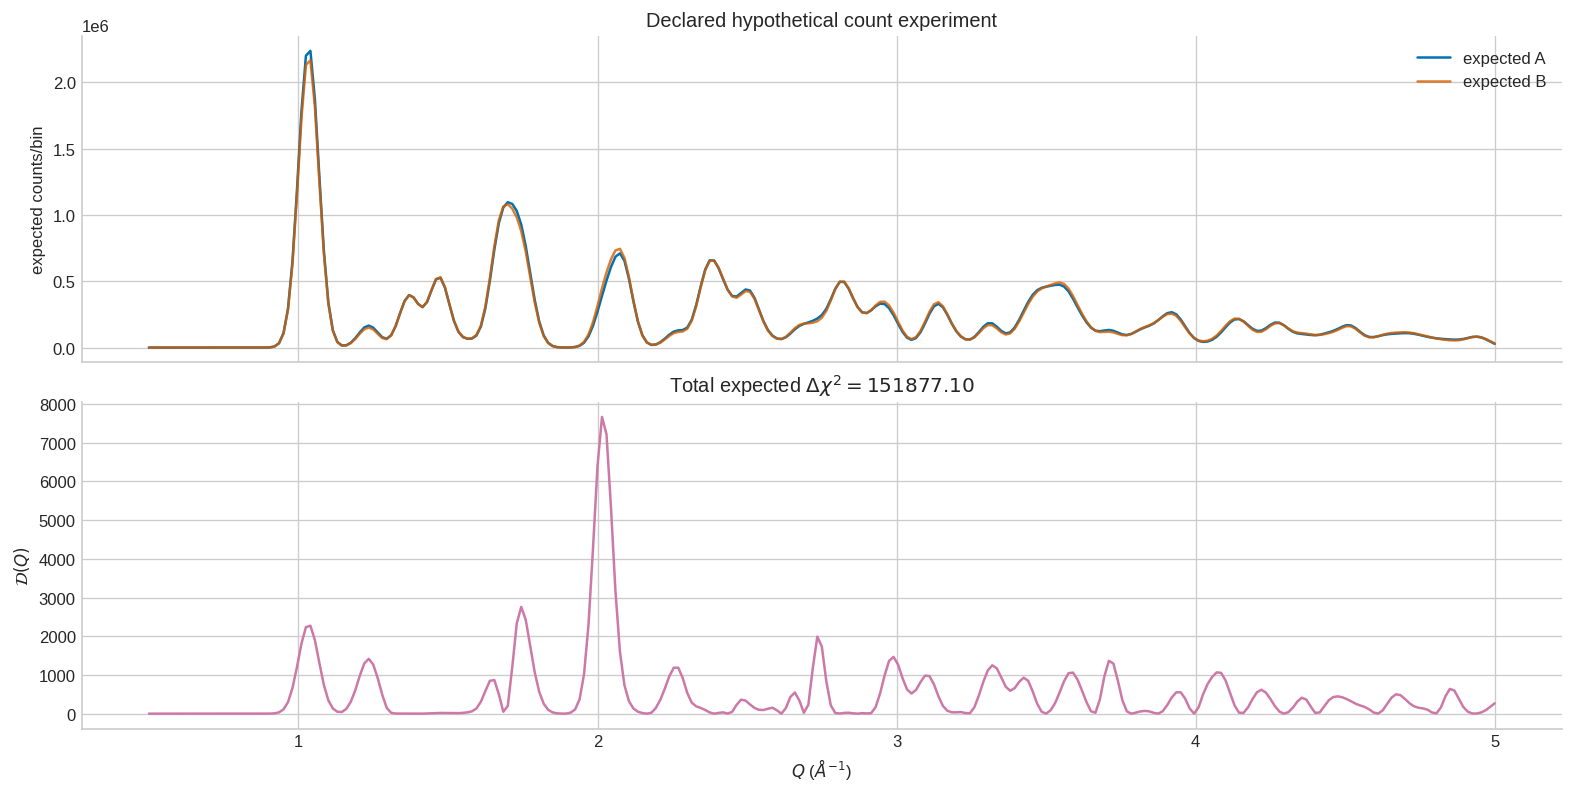

[{'Q': np.float64(2.0149999999999997),
  'local discrimination': np.float64(7668.3754678316)},
 {'Q': np.float64(2.0300000000000002),
  'local discrimination': np.float64(7224.1346696165265)},
 {'Q': np.float64(2.0), 'local discrimination': np.float64(6406.079427778861)},
 {'Q': np.float64(2.045),
  'local discrimination': np.float64(5330.004324938793)},
 {'Q': np.float64(1.9849999999999999),
  'local discrimination': np.float64(4277.884739823943)}]

In [7]:
separation = diagnostic.profile_discrimination
fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True,
                         constrained_layout=True)
axes[0].plot(separation.coordinate, separation.expected_a, color="#0072B2",
             label="expected A")
axes[0].plot(separation.coordinate, separation.expected_b, color="#D55E00",
             alpha=0.8, label="expected B")
axes[0].set(ylabel="expected counts/bin",
            title="Declared hypothetical count experiment")
axes[0].legend()
axes[1].plot(separation.coordinate, separation.pointwise_discrimination,
             color="#CC79A7")
axes[1].set(xlabel=r"$Q$ ($\AA^{-1}$)", ylabel=r"$\mathcal{D}(Q)$",
            title=rf"Total expected $\Delta\chi^2={separation.total_discrimination:.2f}$")
plt.show()
top = np.argsort(separation.pointwise_discrimination)[-5:][::-1]
display([{"Q": separation.coordinate[i],
          "local discrimination": separation.pointwise_discrimination[i]}
         for i in top])


## 7. Declare a restrained, staged refinement policy

### Layman's view

Refinement is not “let every number move.” First fit nuisance terms, then profile
and lattice, then permitted coordinates, and finally a limited joint polish. This
reduces compensation and makes every release auditable.

### Theory and mathematics

$$\chi^2(\theta)=\sum_i[(y_i-\mu_i(\theta))/\sigma_i]^2,$$
while the full objective adds separately reported restraints
$\mathcal L=\mathcal L_{data}+\lambda_{geom}\mathcal L_{geom}+\cdots$.
Symmetry-independent parameters and transformed physical domains are used. A fixed
reflection superset avoids discontinuous peak insertion as the cell changes.

### What to look for

Read active groups and restraints for every stage. A restraint can make the
posterior finite without making that direction identifiable from diffraction.


In [8]:
policy = RefinementPolicy(
    background_degree=1, refine_lattice=True, refine_coordinates=True,
    coordinate_restraint=0.05, holdout_stride=8, diagnostic_points=32,
    stages=(
        OptimizationStage("scale/background", ("scale", "background"), 25, 0.025),
        OptimizationStage("profile/lattice", ("profile", "lattice"), 35, 0.008),
        OptimizationStage("coordinates", ("coordinates",), 35, 0.004),
        OptimizationStage(
            "joint", ("scale", "background", "profile", "lattice", "coordinates"),
            45, 0.002,
        ),
    ),
)
display([{
    "stage": stage.name, "active groups": stage.active,
    "steps": stage.steps, "learning rate": stage.learning_rate,
    "width multiplier": stage.width_multiplier,
} for stage in policy.stages])


[{'stage': 'scale/background',
  'active groups': ('scale', 'background'),
  'steps': 25,
  'learning rate': 0.025,
  'width multiplier': 1.0},
 {'stage': 'profile/lattice',
  'active groups': ('profile', 'lattice'),
  'steps': 35,
  'learning rate': 0.008,
  'width multiplier': 1.0},
 {'stage': 'coordinates',
  'active groups': ('coordinates',),
  'steps': 35,
  'learning rate': 0.004,
  'width multiplier': 1.0},
 {'stage': 'joint',
  'active groups': ('scale',
   'background',
   'profile',
   'lattice',
   'coordinates'),
  'steps': 45,
  'learning rate': 0.002,
  'width multiplier': 1.0}]

## 8. Create an auditable two-model project and refine

`ProjectStore` is the scientist workflow shared by Python, CLI, REST, MCP, and UI.
It copies/checksums inputs, runs every candidate under the same policy, and writes
result JSON, profile and parameter tables, refined CIFs, audit log, and a linked
offline HTML workspace.

The next cell is the longest (usually tens of seconds on CPU). It performs
automatic differentiation and staged optimization for both candidates, then
demonstrates an explicit checkpoint continuation. The resumed calculation is a
new child run; the first result is retained rather than overwritten.


In [9]:
store = ProjectStore.create(
    OUTPUT, dataset_path=PATTERN, model_paths=[MODEL_A, MODEL_B],
    names=["reference motif", "oxygen-shift candidate"], wavelength=1.5406,
    radiation="xray", third_column="sigma", policy=policy,
    title="Complete BraggCalculator characterization tutorial",
    metadata={"synthetic": True,
              "notice": "Teaching example; not independent validation"},
)
first_document, first_result = store.run()
project_document, result = store.run(resume=True)
display(Markdown("### Refinement conclusion\n\n> " + result.conclusion))
display([{
    "candidate": final.name,
    "first-run Rwp": initial.r_wp,
    "resumed Rwp": final.r_wp,
    "resumed chi squared": final.chi_squared,
    "resumed held-out Rwp": final.held_out_r_wp,
    "recommendation": final.recommendation,
} for initial, final in zip(first_result.candidates, result.candidates)])


### Refinement conclusion

> The supplied experiment does not discriminate the refined candidates.

[{'candidate': 'reference motif',
  'first-run Rwp': 0.10132939384671912,
  'resumed Rwp': 0.06773166276595395,
  'resumed chi squared': 0.06329497582736766,
  'resumed held-out Rwp': 0.1005097604404635,
  'recommendation': 'Validate the refined structural parameters across restarts and held-out regions.'},
 {'candidate': 'oxygen-shift candidate',
  'first-run Rwp': 0.10128939620873005,
  'resumed Rwp': 0.06657190777082152,
  'resumed chi squared': 0.06140052409445122,
  'resumed held-out Rwp': 0.09817628854624588,
  'recommendation': 'Validate the refined structural parameters across restarts and held-out regions.'}]

## 9. Read fit, residual, and convergence—without equating fit with truth

### Layman's view

The calculated line should follow observations; standardized residuals report
discrepancies in units of uncertainty. Repeated shapes around peaks point toward
position, width, asymmetry, or structural mismatch.

### Theory and mathematics

$$R_{wp}=\sqrt{{\sum_iw_i(y_i-\mu_i)^2}\over{\sum_iw_i y_i^2}}.$$
It tracks agreement under a fixed weighting model, not the probability that a
structure is correct. Held-out points probe local prediction but are not genuinely
independent data.

### What to look for

Inspect the full residual, held-out agreement, stage trace, and warnings. Never
choose near-equal candidates from the fourth decimal of $R_{wp}$ alone.


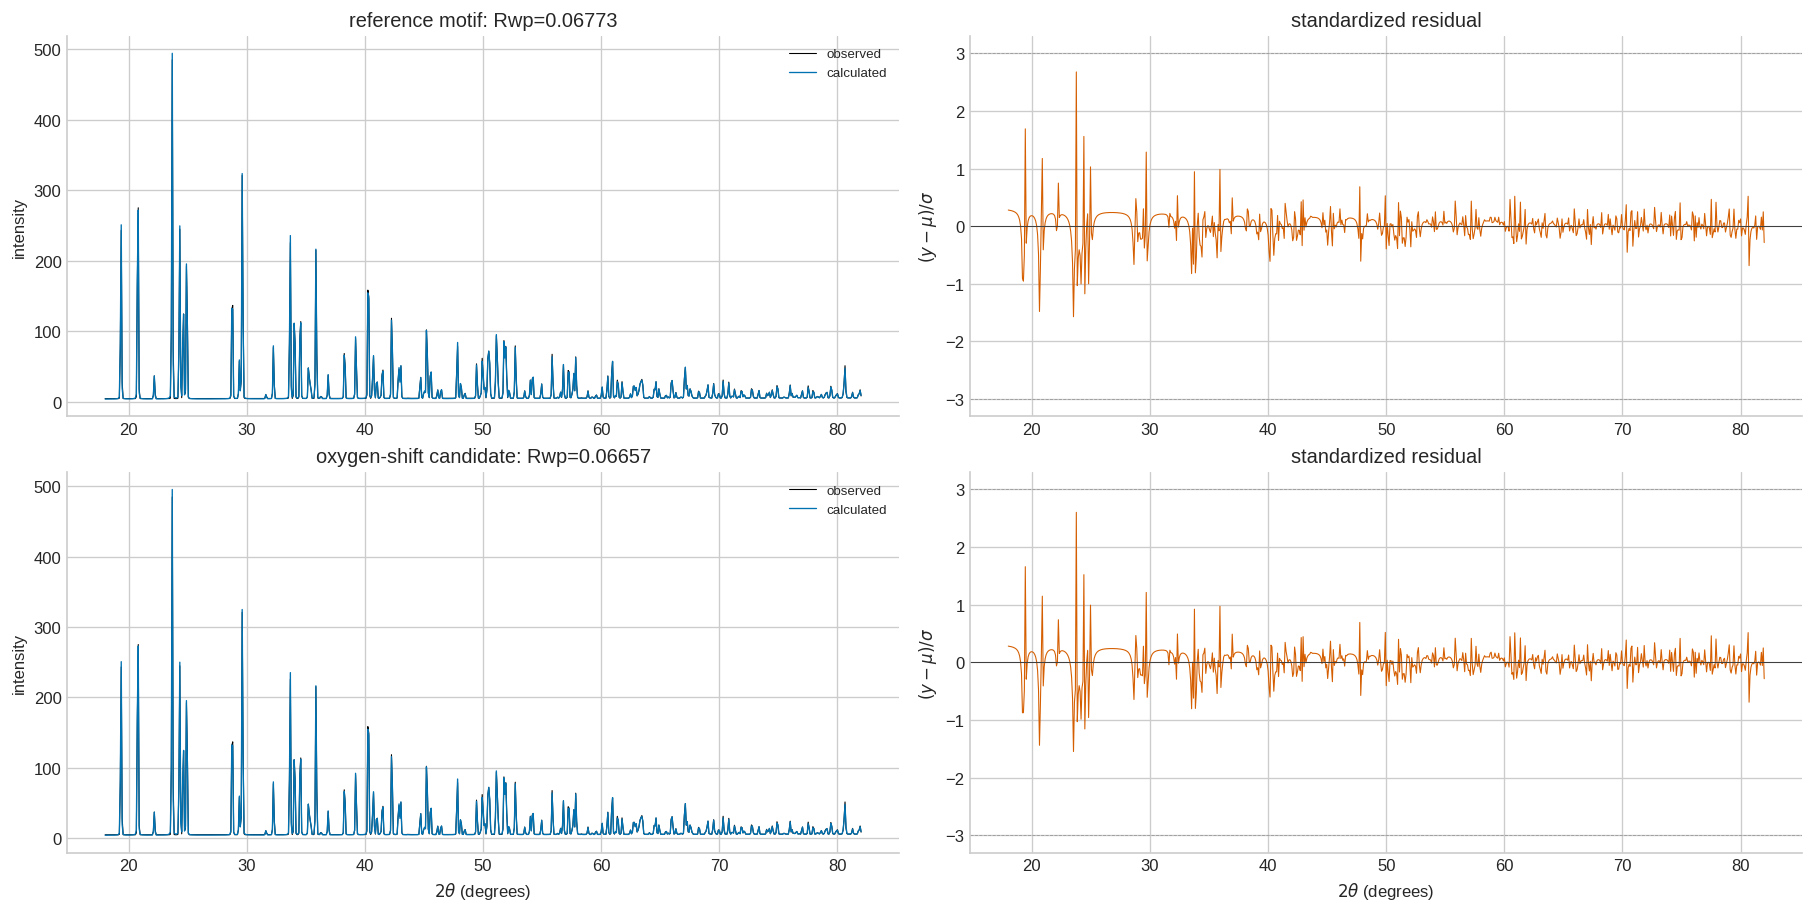

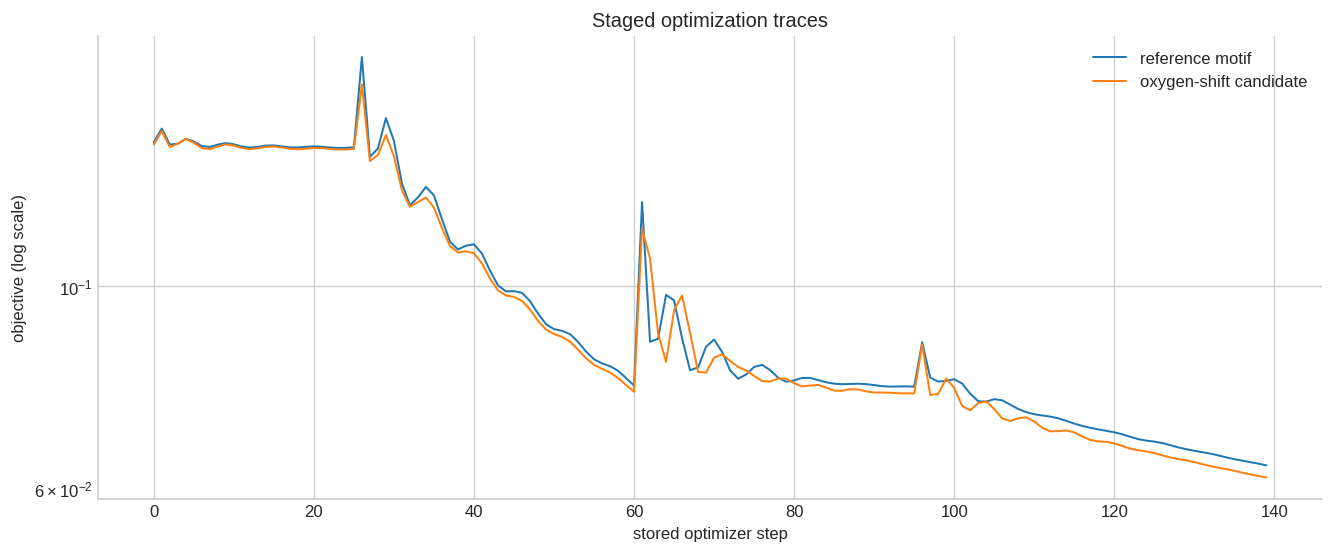

{'fit ranking': ('oxygen-shift candidate', 'reference motif'),
 'refined candidate expected delta chi squared': {'reference motif vs oxygen-shift candidate': 0.11656957482751115},
 'scientific conclusion': 'The supplied experiment does not discriminate the refined candidates.'}

In [10]:
fig, axes = plt.subplots(len(result.candidates), 2, figsize=(15, 7.5),
                         constrained_layout=True)
for row, candidate in enumerate(result.candidates):
    axes[row, 0].plot(dataset.coordinate, dataset.intensity, color="black",
                      lw=0.65, label="observed")
    axes[row, 0].plot(dataset.coordinate, candidate.calculated, color="#0072B2",
                      lw=0.8, label="calculated")
    axes[row, 0].set(ylabel="intensity",
                     title=f"{candidate.name}: Rwp={candidate.r_wp:.5f}")
    axes[row, 0].legend(fontsize=8)
    standardized = candidate.residual/dataset.sigma
    axes[row, 1].plot(dataset.coordinate, standardized, color="#D55E00", lw=0.65)
    axes[row, 1].axhline(0, color="0.25", lw=0.6)
    axes[row, 1].axhline(3, color="0.6", lw=0.5, ls="--")
    axes[row, 1].axhline(-3, color="0.6", lw=0.5, ls="--")
    axes[row, 1].set(ylabel=r"$(y-\mu)/\sigma$", title="standardized residual")
axes[-1, 0].set_xlabel(r"$2\theta$ (degrees)")
axes[-1, 1].set_xlabel(r"$2\theta$ (degrees)")
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
for candidate in result.candidates:
    ax.semilogy(candidate.loss_history, lw=1.2, label=candidate.name)
ax.set(xlabel="stored optimizer step", ylabel="objective (log scale)",
       title="Staged optimization traces")
ax.legend(); plt.show()
display({
    "fit ranking": result.ranking,
    "refined candidate expected delta chi squared": result.pairwise_discrimination,
    "scientific conclusion": result.conclusion,
})


## 10. Identifiability: what parameter combinations does the pattern measure?

### Layman's view

A parameter can strongly change the pattern yet remain inseparable from another
parameter producing nearly the same change. Sensitivity asks “does it matter?”;
correlation and rank ask “can it be determined independently?”

### Theory and mathematics

Automatic differentiation gives $J_{ij}=\partial\mu_i/\partial p_j$.
Sensitivity is $s_j=\sqrt{J_j^TWJ_j}$ and the local normal/Fisher matrix is
$H=J^TWJ$. Collinear columns create correlations near ±1 and small singular values.
Data rank below parameter count means a local parameter combination is not
independently measured. Priors add posterior curvature but are reported separately.

### What to look for

Check data rank before standard errors. “Posterior full rank” with “data rank
deficient” means restraints stabilize the answer; the experiment did not measure
the missing direction.


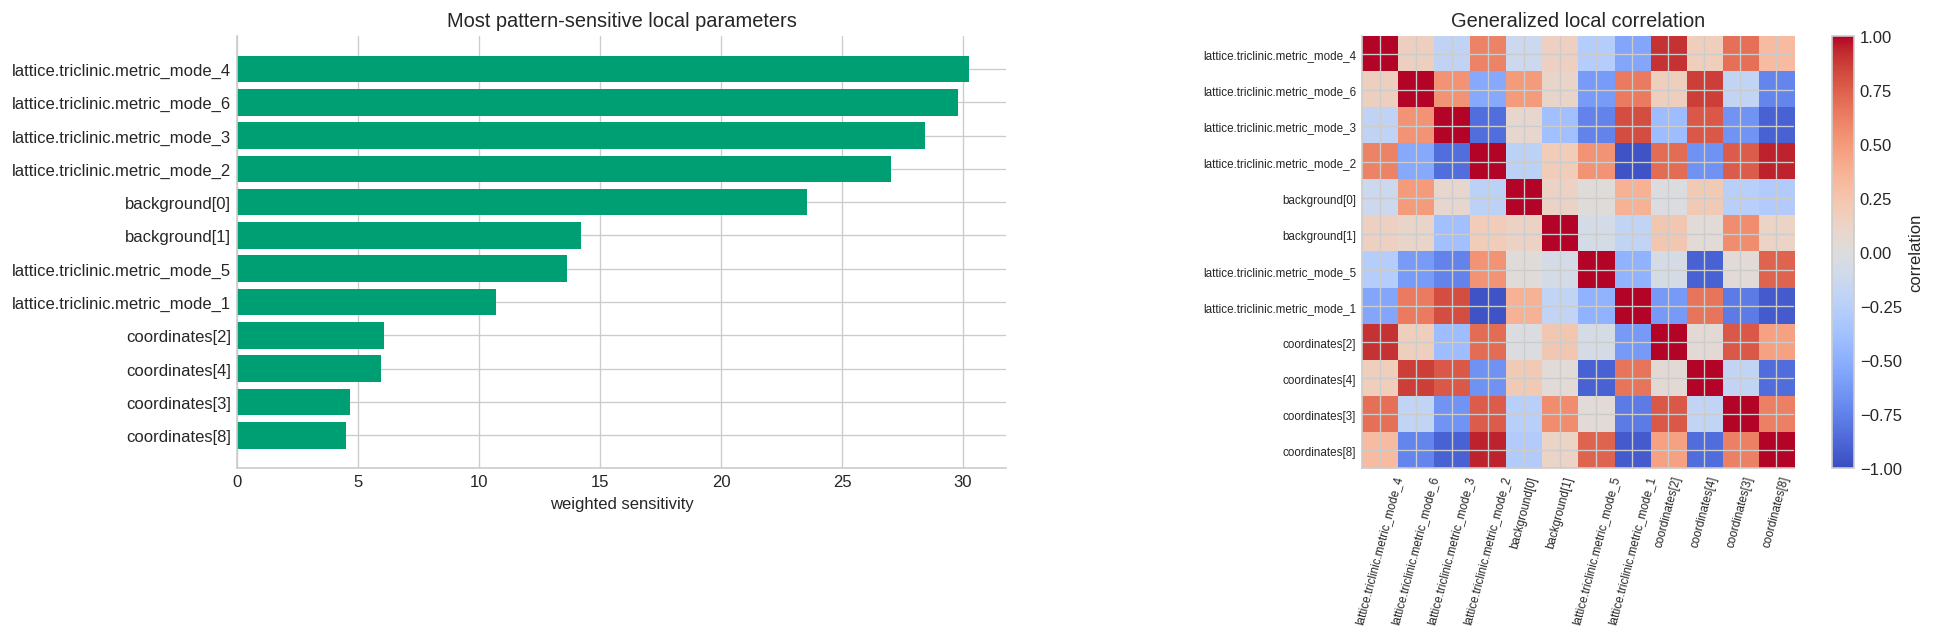

{'data rank / parameter count': '24 / 27',
 'data covariance identifiable': False,
 'prior rank': 12,
 'posterior rank / parameter count': '27 / 27',
 'posterior covariance identifiable': True,
 'maximum absolute correlation': 0.997926253467065,
 'warning': 'Subsampled local Gaussian approximation conditional on the supplied noise, forward and prior models; inspect bootstrap coverage before uncertainty use.'}

In [11]:
identity = result.candidates[0].identifiability
parameter_names = np.asarray(identity["parameter_names"])
sensitivity = np.asarray(identity["sensitivity"])
correlation = np.asarray(identity["correlation"])
selected = np.argsort(sensitivity)[-12:][::-1]
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), constrained_layout=True)
axes[0].barh(np.arange(len(selected)), sensitivity[selected], color="#009E73")
axes[0].set(yticks=np.arange(len(selected)), yticklabels=parameter_names[selected],
            xlabel="weighted sensitivity",
            title="Most pattern-sensitive local parameters")
axes[0].invert_yaxis()
corr_selected = correlation[np.ix_(selected, selected)]
image = axes[1].imshow(corr_selected, vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set(xticks=np.arange(len(selected)), yticks=np.arange(len(selected)),
            xticklabels=parameter_names[selected],
            yticklabels=parameter_names[selected],
            title="Generalized local correlation")
axes[1].tick_params(axis="x", rotation=75, labelsize=7)
axes[1].tick_params(axis="y", labelsize=7)
fig.colorbar(image, ax=axes[1], label="correlation")
plt.show()
display({
    "data rank / parameter count":
        f'{identity["data_rank"]} / {identity["parameter_count"]}',
    "data covariance identifiable": identity["data_covariance_is_identifiable"],
    "prior rank": identity["prior_rank"],
    "posterior rank / parameter count":
        f'{identity["posterior_rank"]} / {identity["parameter_count"]}',
    "posterior covariance identifiable":
        identity["posterior_covariance_is_identifiable"],
    "maximum absolute correlation": identity["maximum_absolute_correlation"],
    "warning": identity["warning"],
})


## 11. Design a better measurement

### Layman's view

When present data cannot distinguish candidates, the forward model can compare
declared alternatives: better resolution, more counts, wider range, or different
X-ray/neutron contrast.

### Theory and mathematics

Each configuration recomputes $\sum_i(\mu_A-\mu_B)^2/\sigma_i^2$ under an explicit
count/background model. Here we compare the **exported refined structures**, held
fixed under each proposed measurement. The score does not simulate nuisance or
structural re-refinement under the new experiment. It is predicted information
under the simulator—not a guarantee against unmodelled impurities, texture,
aberrations, systematic error, or model flexibility.

### What to look for

Compare configurations only after checking count, background, range, wavelength,
and FWHM assumptions. The most-informative $Q$ suggests where to inspect or count.


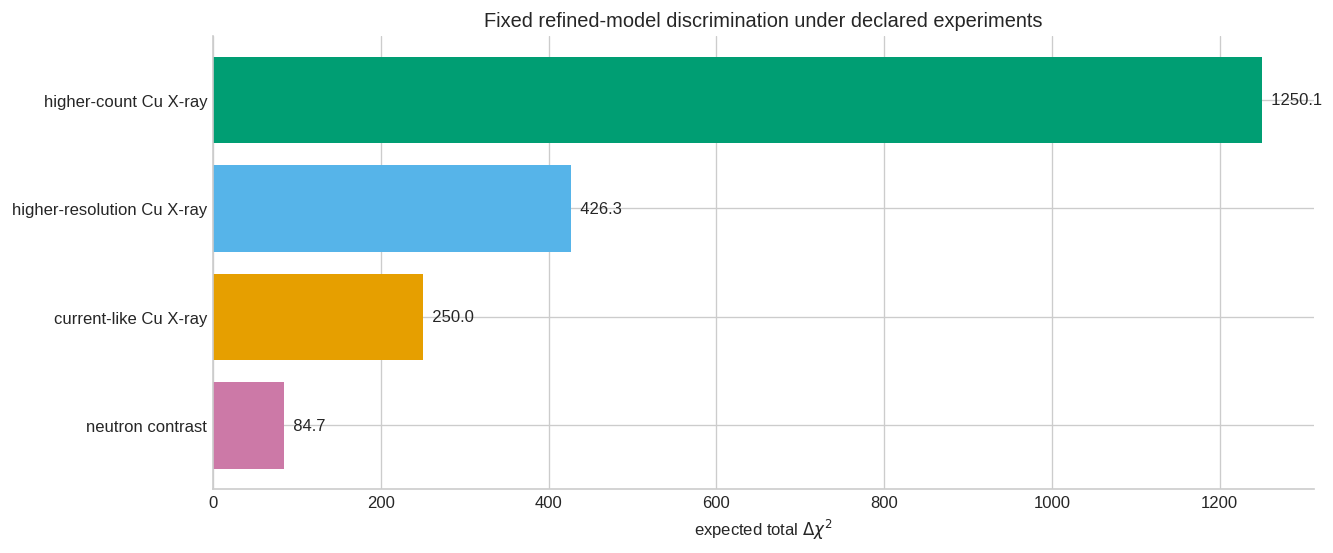

[{'rank': 1,
  'experiment': 'higher-count Cu X-ray',
  'expected delta chi squared': 1250.0968397304132,
  'most informative Q': 2.09,
  'assumptions': {'q_step': 0.01,
   'count_scale': 500.0,
   'background_density': 1.0,
   'variance': 'symmetric mean-count Poisson approximation'}},
 {'rank': 2,
  'experiment': 'higher-resolution Cu X-ray',
  'expected delta chi squared': 426.25146613284534,
  'most informative Q': 3.215,
  'assumptions': {'q_step': 0.005,
   'count_scale': 100.0,
   'background_density': 1.0,
   'variance': 'symmetric mean-count Poisson approximation'}},
 {'rank': 3,
  'experiment': 'current-like Cu X-ray',
  'expected delta chi squared': 250.01935051395648,
  'most informative Q': 2.09,
  'assumptions': {'q_step': 0.01,
   'count_scale': 100.0,
   'background_density': 1.0,
   'variance': 'symmetric mean-count Poisson approximation'}},
 {'rank': 4,
  'experiment': 'neutron contrast',
  'expected delta chi squared': 84.70331213437322,
  'most informative Q': 3.47,

In [12]:
configurations = [
    {"name": "current-like Cu X-ray", "radiation": "xray", "wavelength": 1.5406,
     "q_range": (0.5, 5), "q_step": 0.01, "fwhm_q": 0.08,
     "count_scale": 100, "background_density": 1},
    {"name": "higher-resolution Cu X-ray", "radiation": "xray",
     "wavelength": 1.5406, "q_range": (0.5, 5), "q_step": 0.005,
     "fwhm_q": 0.025, "count_scale": 100, "background_density": 1},
    {"name": "higher-count Cu X-ray", "radiation": "xray", "wavelength": 1.5406,
     "q_range": (0.5, 5), "q_step": 0.01, "fwhm_q": 0.08,
     "count_scale": 500, "background_density": 1},
    {"name": "neutron contrast", "radiation": "neutron", "wavelength": 1.8,
     "q_range": (0.5, 5), "q_step": 0.01, "fwhm_q": 0.08,
     "count_scale": 100, "background_density": 1},
]
current_run = project_document["runs"][-1]
refined_files = current_run["artifacts"]["refined_cif"]
refined_a = Structure.from_file(OUTPUT / refined_files["reference motif"])
refined_b = Structure.from_file(OUTPUT / refined_files["oxygen-shift candidate"])
recommendations = suggest_measurements(refined_a, refined_b, configurations)
fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
measurement_names = [item.name for item in recommendations]
scores = [item.total_discrimination for item in recommendations]
bars = ax.barh(np.arange(len(measurement_names)), scores,
               color=["#009E73", "#56B4E9", "#E69F00", "#CC79A7"])
ax.set(yticks=np.arange(len(measurement_names)), yticklabels=measurement_names,
       xlabel=r"expected total $\Delta\chi^2$",
       title="Fixed refined-model discrimination under declared experiments")
ax.invert_yaxis()
for bar, score in zip(bars, scores):
    ax.text(score, bar.get_y()+bar.get_height()/2, f"  {score:.1f}", va="center")
plt.show()
display([{
    "rank": index+1, "experiment": item.name,
    "expected delta chi squared": item.total_discrimination,
    "most informative Q": item.most_informative_q,
    "assumptions": item.assumptions,
} for index, item in enumerate(recommendations)])


## 12. Provenance and portable artifacts

The project survives the Python session: copied/checksummed inputs, policy, run
lineage, structured result, profile/parameter tables, refined CIFs, audit log, and
linked HTML workspace are written together. `store.run(resume=True)` creates a
child run from saved raw parameters; it does not overwrite its parent, and the
fresh optimizer segment is recorded.


In [13]:
latest = project_document["runs"][-1]
display({
    "project id": project_document["project_id"],
    "run id": latest["run_id"], "parent run": latest["parent_run_id"],
    "dataset hash": project_document["dataset"]["sha256"],
    "model hashes": {item["name"]: item["sha256"]
                     for item in project_document["models"]},
    "artifacts": latest["artifacts"],
})
workspace = OUTPUT / latest["artifacts"]["workspace_html"]
print(f"Offline linked workspace: {shown(workspace)}")
print(f"Project manifest: {shown(OUTPUT / 'project.json')}")
print(f"Audit log: {shown(OUTPUT / 'audit.json')}")


{'project id': '2b4de164-2148-4e23-909a-67694b93661c',
 'run id': 'run-0002',
 'parent run': 'run-0001',
 'dataset hash': '0aec3e605d4e533ee2ccaaab602415d530f47fee4e07ef89ffcc9a7a559a49c6',
 'model hashes': {'reference motif': '276d0603aa8a36e9ee1ec61704e200aadc20d891a3cfa09a8183f8794632b0ef',
  'oxygen-shift candidate': '616e1843187ca41a329baeb8ce064952e58a33c4806a1864b52ba2f667be8eb2'},
 'artifacts': {'result_json': 'runs/run-0002/result.json',
  'profiles_csv': 'runs/run-0002/profiles.csv',
  'parameters_csv': 'runs/run-0002/parameters.csv',
  'refined_cif': {'reference motif': 'runs/run-0002/reference-motif-refined.cif',
   'oxygen-shift candidate': 'runs/run-0002/oxygen-shift-candidate-refined.cif'},
  'workspace_html': 'runs/run-0002/workspace.html',
  'audit_json': 'audit.json'}}

Offline linked workspace: notebooks/tutorial-output/runs/run-0002/workspace.html
Project manifest: notebooks/tutorial-output/project.json
Audit log: notebooks/tutorial-output/audit.json


## 13. The parallel guided UI

Notebook and UI call the same physics, diagnostics, refinement, project, and export
layers. Use this notebook for transparent code, equations, custom plots, and a
reproducible narrative. Use the UI to upload files and navigate linked diagnostics
without Python.

```bash
bragg-ui --root bragg-ui-projects --host 127.0.0.1 --port 8766
```

Open `http://127.0.0.1:8766`, click **Load the complete tutorial**, inspect the
release policy, and click **Run refinement**. Uploaded structural parameters cannot
be released without explicit acknowledgement.

| Notebook result | UI tab |
|---|---|
| inputs and calculated profile | Tutorial / Fit |
| standardized discrepancy | Residual |
| relationship and pair distribution | Structures |
| complex mismatch disk | Amplitude + phase |
| resolution groups | Peak overlap |
| Jacobian rank and correlations | Identifiability |
| transformed/refined values | Parameters |
| alternative experiments | Experiment design |
| hashes, run lineage, files | Provenance |

![Guided BraggCalculator UI](../demo/end_to_end_ui.png)


## 14. Scientific conclusion and next use on real data

Both tutorial candidates reach similar fits. Their complex structure factors are
not identical, but after powder averaging, broadening, uncertainty scaling, and
fair refinement, this pattern does not discriminate them:

> **Do not force a winner. Report the ambiguity, rank/correlation warnings, and
> measurement conditions predicted to add information.**

For real characterization: use the actual spectrum, geometry, covariance/mask,
background and profile assumptions; release structural groups in stages; report
chemistry restraints separately; test restarts, held-out ranges and candidates;
inspect rank/null directions before uncertainties; and archive the project bundle.

Advanced package paths not run in this compact example include constrained
occupancies, isotropic/anisotropic displacement tensors, rigid bodies, multiphase
simplexes, correlated covariance, Poisson likelihood, parametric bootstrap,
superstructure diagnostics, GSAS ingestion, public reference validation, REST/MCP,
and the frozen publication benchmark. See the root `README.md`, `docs/api.md`, and
`docs/characterization-roadmap.md`.
